# Time-Varying Combination Weights

Static combination weights assume that the relative performance of models
is **constant over time**. In practice, this is rarely the case:

- Structural breaks can change which model is best.
- Some models may perform well in recessions but poorly in expansions.
- Data revisions and regime changes shift the optimal combination.

This notebook explores methods that **adapt combination weights over time**:

- **Exponential Forgetting**: Weights based on exponentially smoothed MSE.
- **Regime-Dependent Weights**: Different weights for different economic regimes.
- **Online Learning (EWAF)**: Exponentially Weighted Average Forecaster.

**Topics covered:**
- Time-varying performance diagnostics
- Exponential forgetting with tunable decay
- Regime-dependent combination
- Online learning algorithms
- Weight evolution visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from forecastbox.combination import (
    SimpleCombiner,
    WeightedCombiner,
    TimeVaryingCombiner,
)
from forecastbox.core.forecast import Forecast
from forecastbox.metrics import mae, rmse

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 5)
np.random.seed(42)

## 1. Why Time-Varying Weights?

The assumption of **structural stability** -- that the DGP and model relationships
are constant -- is often violated in macro forecasting. Models that performed well
in the past may deteriorate due to:

- **Regime changes**: e.g., high vs. low inflation environments
- **Structural breaks**: e.g., policy shifts, financial crises
- **Model misspecification**: some models capture certain dynamics better than others

Let's first visualize how model performance evolves over time.

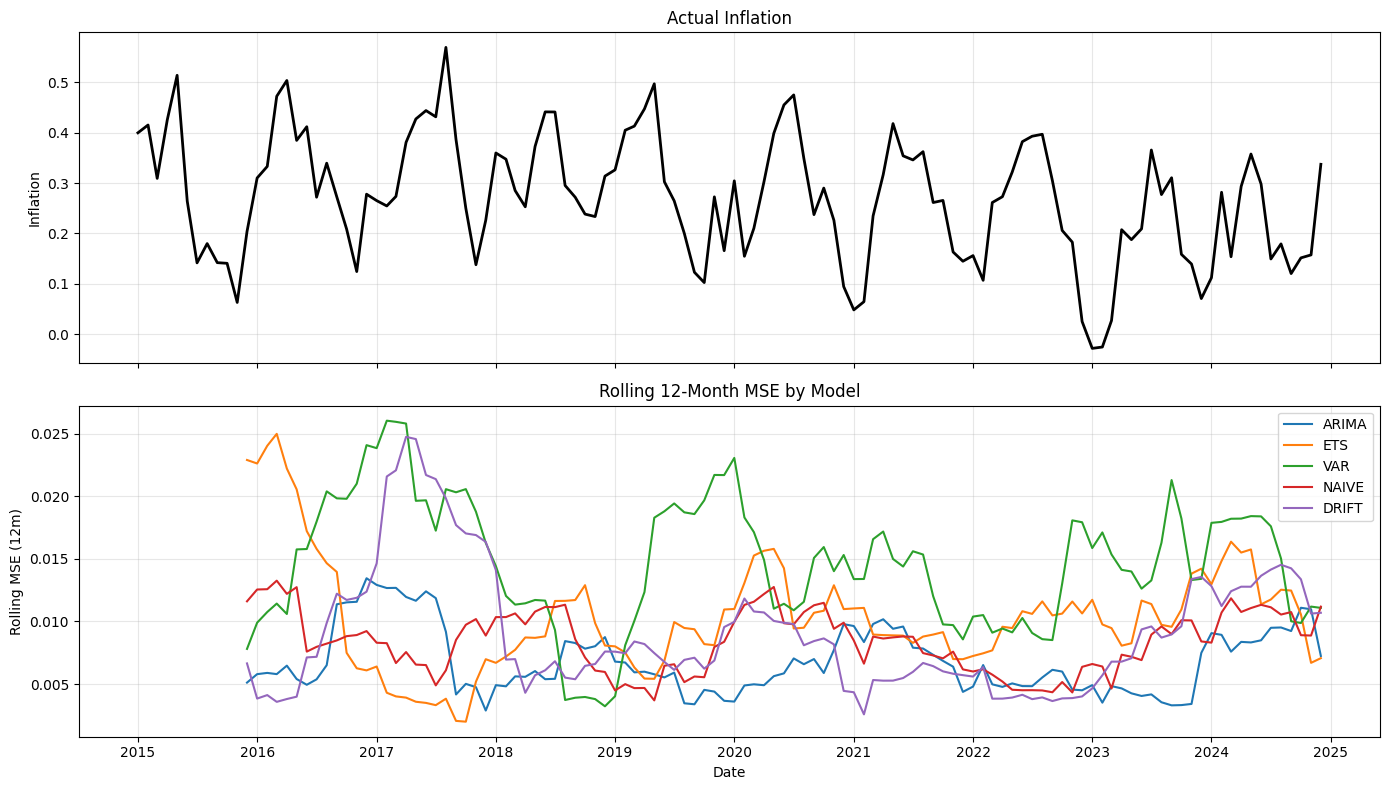

Observation: Model performance varies substantially over time.
This motivates time-varying combination weights.


In [2]:
# Load data
df = pd.read_csv("../../data/inflation_forecasts.csv", parse_dates=["date"])

model_cols = ["fc_arima", "fc_ets", "fc_var", "fc_naive", "fc_drift"]
model_names = [c.replace("fc_", "").upper() for c in model_cols]

# Compute rolling 12-month squared errors for each model
window = 12
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Actual series
axes[0].plot(df["date"], df["actual"], "k-", linewidth=2)
axes[0].set_ylabel("Inflation")
axes[0].set_title("Actual Inflation")
axes[0].grid(True, alpha=0.3)

# Panel 2: Rolling MSE
for col, name in zip(model_cols, model_names):
    sq_errors = (df["actual"] - df[col]) ** 2
    rolling_mse = sq_errors.rolling(window=window).mean()
    axes[1].plot(df["date"], rolling_mse, label=name, linewidth=1.5)

axes[1].set_ylabel("Rolling MSE (12m)")
axes[1].set_xlabel("Date")
axes[1].set_title("Rolling 12-Month MSE by Model")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observation: Model performance varies substantially over time.")
print("This motivates time-varying combination weights.")

## 2. Exponential Forgetting

The **exponential forgetting** approach updates the MSE of each model using
exponential smoothing:

$$\text{MSE}_{k,t} = \lambda \cdot \text{MSE}_{k,t-1} + (1 - \lambda) \cdot (y_t - \hat{y}_{k,t})^2$$

The combination weights at time $t$ are then:

$$w_{k,t} = \frac{1/\text{MSE}_{k,t}}{\sum_{j=1}^{K} 1/\text{MSE}_{j,t}}$$

The **decay parameter** $\lambda \in (0, 1)$ controls the memory:
- $\lambda$ close to 1: long memory, slow adaptation (similar to static weights)
- $\lambda$ close to 0: short memory, fast adaptation (volatile weights)

In [3]:
# Use all data for time-varying analysis
actual_all = df["actual"].values
forecasts_all = [df[col].values for col in model_cols]

# Exponential forgetting with decay=0.95
tv_combiner = TimeVaryingCombiner(decay=0.95)
tv_combiner.fit(forecasts_all, actual_all)

print("Exponential Forgetting (decay=0.95):")
print(f"  Final weights (t={len(actual_all)}):")
for name, w in zip(model_names, tv_combiner.weights_):
    print(f"    {name:8s}: {w:.4f}")

# Produce combined forecast using final weights on test period
n_train = 80
forecasts_train_tv = [df[col].values[:n_train] for col in model_cols]
actual_train_tv = df["actual"].values[:n_train]

tv_combiner_train = TimeVaryingCombiner(decay=0.95)
tv_combiner_train.fit(forecasts_train_tv, actual_train_tv)

forecasts_test = [
    Forecast(point=df[col].values[n_train:], model_name=name)
    for col, name in zip(model_cols, model_names)
]
fc_tv = tv_combiner_train.combine(forecasts_test)

actual_test = df["actual"].values[n_train:]
print(f"\n  Test MAE:  {mae(actual_test, fc_tv.point):.4f}")
print(f"  Test RMSE: {rmse(actual_test, fc_tv.point):.4f}")

# Compare different decay values
print("\nComparing decay values:")
for decay in [0.8, 0.9, 0.95, 0.99]:
    tv = TimeVaryingCombiner(decay=decay)
    tv.fit(forecasts_train_tv, actual_train_tv)
    fc = tv.combine(forecasts_test)
    print(f"  decay={decay:.2f}  RMSE={rmse(actual_test, fc.point):.4f}")

Exponential Forgetting (decay=0.95):
  Final weights (t=120):
    ARIMA   : 0.2696
    ETS     : 0.1953
    VAR     : 0.1474
    NAIVE   : 0.1980
    DRIFT   : 0.1897

  Test MAE:  0.0344
  Test RMSE: 0.0417

Comparing decay values:
  decay=0.80  RMSE=0.0425
  decay=0.90  RMSE=0.0419
  decay=0.95  RMSE=0.0417
  decay=0.99  RMSE=0.0406


## 3. Regime-Dependent Weights

Instead of smooth time variation, we can use **regime-dependent** weights
that switch between predefined states. For example:

- **High inflation regime**: actual > median
- **Low inflation regime**: actual <= median

We estimate separate combination weights for each regime using
historical data, then apply the appropriate weights based on the current regime.

In [4]:
# Regime-dependent weights using WeightedCombiner for each regime
train_df = df.iloc[:n_train]
test_df = df.iloc[n_train:]

median_inflation = train_df["actual"].median()
print(f"Inflation median (training): {median_inflation:.4f}")

# Split training data by regime
high_mask = train_df["actual"] > median_inflation
low_mask = ~high_mask

# Estimate weights for each regime
fc_train_high = [train_df.loc[high_mask, col].values for col in model_cols]
fc_train_low = [train_df.loc[low_mask, col].values for col in model_cols]

combiner_high = WeightedCombiner(method="inverse_mse")
combiner_high.fit(fc_train_high, train_df.loc[high_mask, "actual"].values)

combiner_low = WeightedCombiner(method="inverse_mse")
combiner_low.fit(fc_train_low, train_df.loc[low_mask, "actual"].values)

print(f"\nHigh inflation regime weights ({high_mask.sum()} obs):")
for name, w in zip(model_names, combiner_high.weights_):
    print(f"  {name:8s}: {w:.4f}")

print(f"\nLow inflation regime weights ({low_mask.sum()} obs):")
for name, w in zip(model_names, combiner_low.weights_):
    print(f"  {name:8s}: {w:.4f}")

# Apply regime-dependent combination to test set
# Use previous period actual to determine regime
regime_preds = np.zeros(len(test_df))
for i in range(len(test_df)):
    # Determine regime based on previous actual value
    if i == 0:
        prev_actual = train_df["actual"].iloc[-1]
    else:
        prev_actual = test_df["actual"].iloc[i - 1]

    fc_point = np.array([test_df[col].iloc[i] for col in model_cols])

    if prev_actual > median_inflation:
        regime_preds[i] = np.dot(combiner_high.weights_, fc_point)
    else:
        regime_preds[i] = np.dot(combiner_low.weights_, fc_point)

print(f"\nRegime-Dependent Combination:")
print(f"  MAE:  {mae(actual_test, regime_preds):.4f}")
print(f"  RMSE: {rmse(actual_test, regime_preds):.4f}")

Inflation median (training): 0.3028

High inflation regime weights (40 obs):
  ARIMA   : 0.2762
  ETS     : 0.2584
  VAR     : 0.0858
  NAIVE   : 0.2004
  DRIFT   : 0.1792

Low inflation regime weights (40 obs):
  ARIMA   : 0.2548
  ETS     : 0.1432
  VAR     : 0.1800
  NAIVE   : 0.2138
  DRIFT   : 0.2082

Regime-Dependent Combination:
  MAE:  0.0346
  RMSE: 0.0417


## 4. Online Learning (EWAF)

The **Exponentially Weighted Average Forecaster (EWAF)** is an online learning
algorithm from prediction with expert advice (Cesa-Bianchi & Lugosi, 2006).

At each time step $t$, the weights are updated based on cumulative losses:

$$w_{k,t} \propto w_{k,t-1} \cdot \exp\left(-\eta \cdot \ell(y_t, \hat{y}_{k,t})\right)$$

where $\eta$ is the **learning rate** and $\ell$ is the loss function (typically squared error).

We implement this using `TimeVaryingCombiner` with a low decay parameter,
which approximates the EWAF behavior through exponential smoothing of MSE.

Online Learning (EWAF-style, decay=0.85):
  Final weights:
    ARIMA   : 0.2427
    ETS     : 0.2498
    VAR     : 0.1769
    NAIVE   : 0.1583
    DRIFT   : 0.1723

Rolling evaluation (test period):
  Static RMSE:  0.0417
  Online RMSE:  0.0483


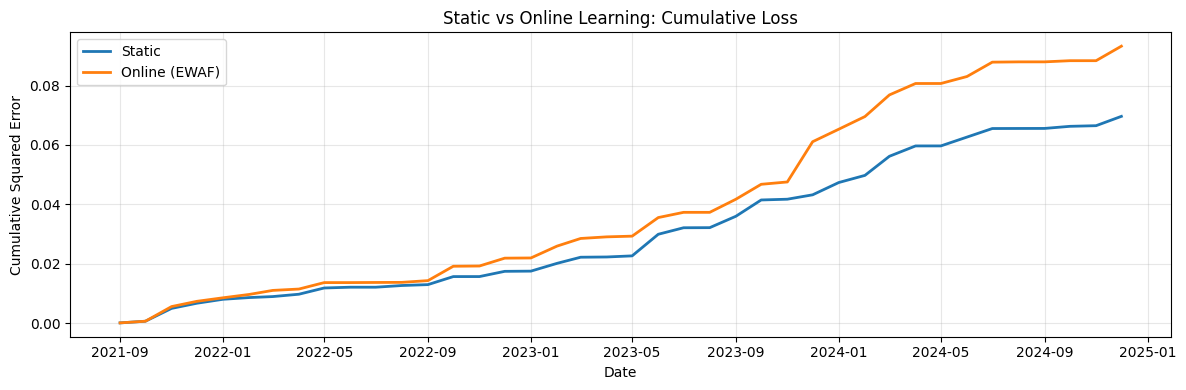

In [5]:
# Online learning via TimeVaryingCombiner with aggressive decay
# Low decay = short memory = fast adaptation (online learning style)
online_combiner = TimeVaryingCombiner(decay=0.85)
online_combiner.fit(forecasts_all, actual_all)

print("Online Learning (EWAF-style, decay=0.85):")
print(f"  Final weights:")
for name, w in zip(model_names, online_combiner.weights_):
    print(f"    {name:8s}: {w:.4f}")

# Compare: static vs online learning on test set via rolling evaluation
static_errors = []
online_errors = []

for t in range(n_train, len(df)):
    # Static: use weights from full training set
    fc_point = np.array([df[col].iloc[t] for col in model_cols])
    static_pred = np.dot(tv_combiner_train.weights_, fc_point)
    static_errors.append((df["actual"].iloc[t] - static_pred) ** 2)

    # Online: update weights with all data up to t-1
    fc_up_to_t = [df[col].values[:t] for col in model_cols]
    actual_up_to_t = df["actual"].values[:t]
    online_t = TimeVaryingCombiner(decay=0.85)
    online_t.fit(fc_up_to_t, actual_up_to_t)
    online_pred = np.dot(online_t.weights_, fc_point)
    online_errors.append((df["actual"].iloc[t] - online_pred) ** 2)

print(f"\nRolling evaluation (test period):")
print(f"  Static RMSE:  {np.sqrt(np.mean(static_errors)):.4f}")
print(f"  Online RMSE:  {np.sqrt(np.mean(online_errors)):.4f}")

# Plot cumulative squared errors
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["date"].iloc[n_train:], np.cumsum(static_errors), label="Static", linewidth=2)
ax.plot(df["date"].iloc[n_train:], np.cumsum(online_errors), label="Online (EWAF)", linewidth=2)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Squared Error")
ax.set_title("Static vs Online Learning: Cumulative Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Tracking Weight Evolution

One of the key advantages of time-varying methods is the ability to
**visualize how model importance changes over time**. This provides
insights into which models are most useful in different periods.

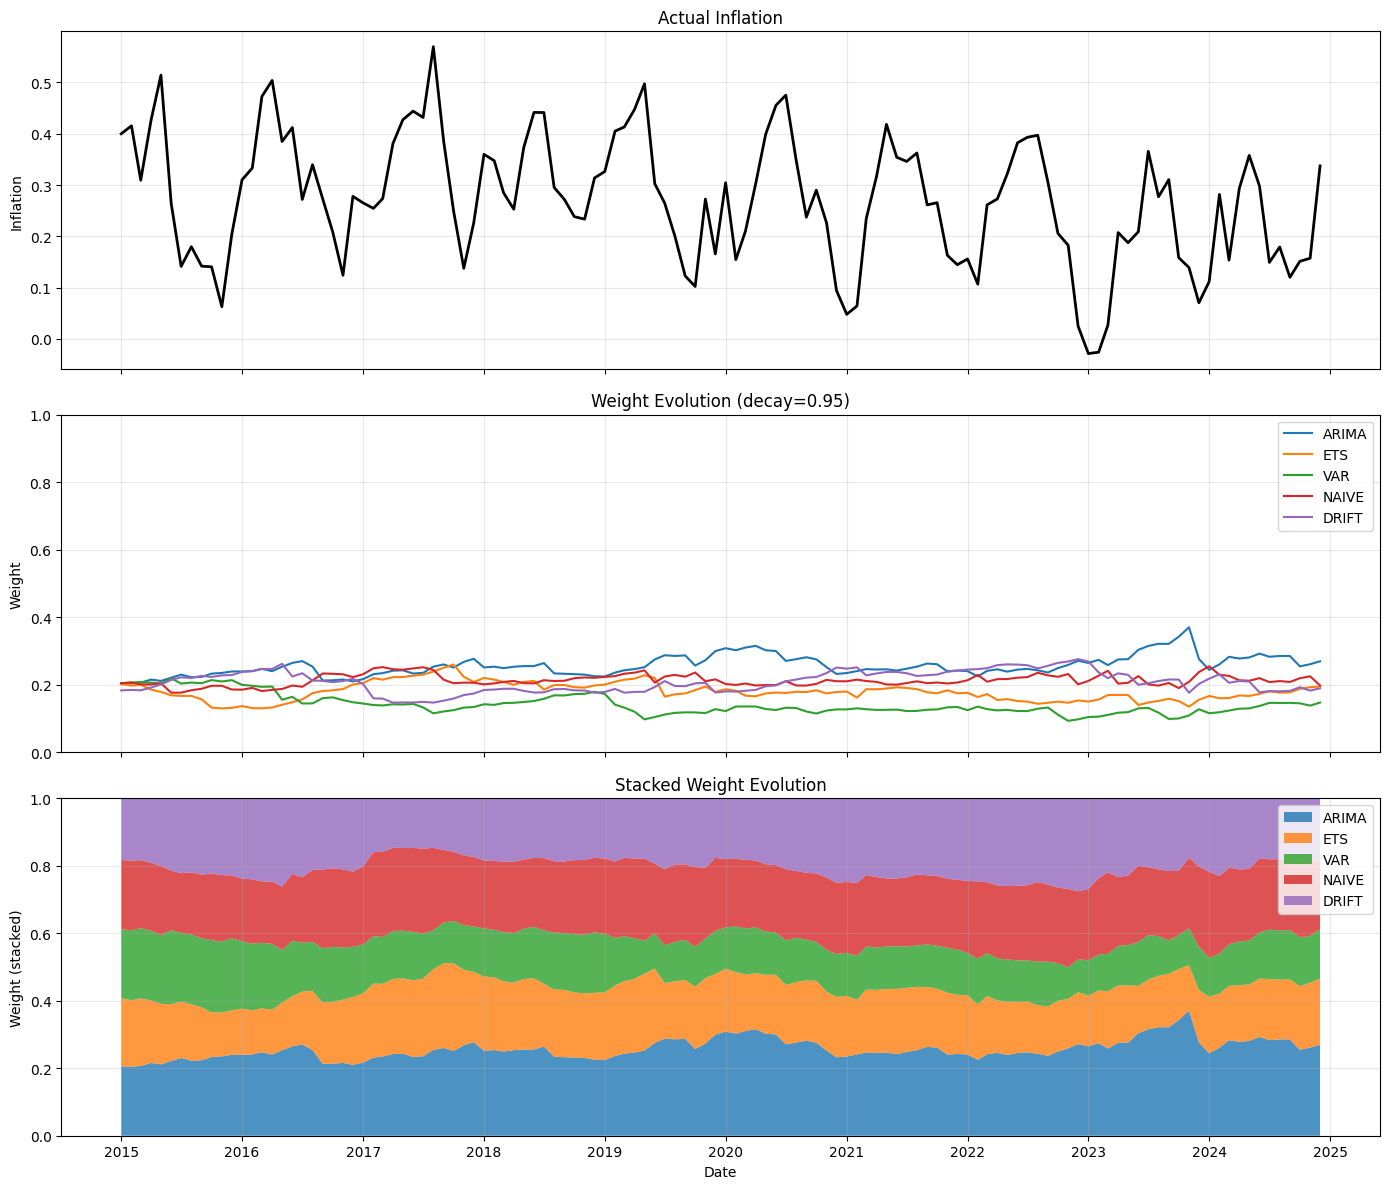

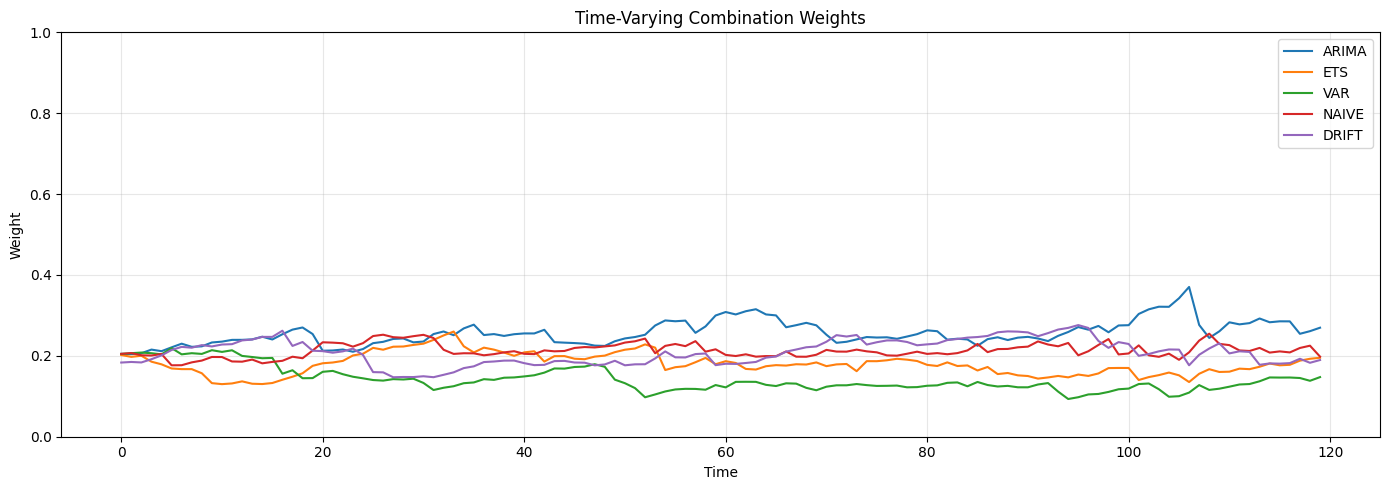

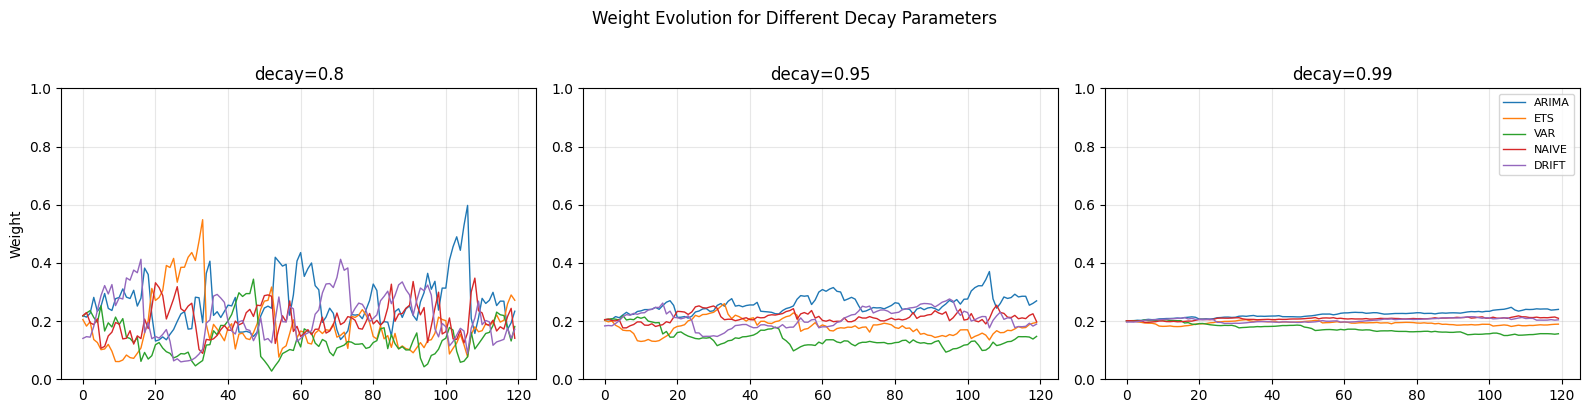

In [6]:
# Plot weight evolution using the built-in plot_weights method
tv_full = TimeVaryingCombiner(decay=0.95)
tv_full.fit(forecasts_all, actual_all)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Actual inflation
axes[0].plot(df["date"], df["actual"], "k-", linewidth=2)
axes[0].set_ylabel("Inflation")
axes[0].set_title("Actual Inflation")
axes[0].grid(True, alpha=0.3)

# Panel 2: Weight evolution (line plot)
for i, name in enumerate(model_names):
    axes[1].plot(df["date"], tv_full.weights_history_[:, i],
                 label=name, linewidth=1.5)
axes[1].set_ylabel("Weight")
axes[1].set_title("Weight Evolution (decay=0.95)")
axes[1].legend(loc="upper right")
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

# Panel 3: Stacked area chart
axes[2].stackplot(
    df["date"],
    *[tv_full.weights_history_[:, i] for i in range(len(model_names))],
    labels=model_names,
    alpha=0.8,
)
axes[2].set_ylabel("Weight (stacked)")
axes[2].set_xlabel("Date")
axes[2].set_title("Stacked Weight Evolution")
axes[2].legend(loc="upper right")
axes[2].set_ylim(0, 1)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Also use the built-in plot_weights method
fig, ax = plt.subplots(figsize=(14, 5))
tv_full.plot_weights(model_names=model_names, ax=ax)
plt.tight_layout()
plt.show()

# Compare different decay parameters
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, decay in zip(axes, [0.8, 0.95, 0.99]):
    tv_temp = TimeVaryingCombiner(decay=decay)
    tv_temp.fit(forecasts_all, actual_all)
    for i, name in enumerate(model_names):
        ax.plot(tv_temp.weights_history_[:, i], label=name, linewidth=1)
    ax.set_title(f"decay={decay}")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    if ax == axes[0]:
        ax.set_ylabel("Weight")
    if ax == axes[-1]:
        ax.legend(fontsize=8)

plt.suptitle("Weight Evolution for Different Decay Parameters", y=1.02)
plt.tight_layout()
plt.show()

## Exercise 1: Find optimal forgetting factor via CV

Use the first 80 observations as a training set and the last 40 as a test set.
Perform a grid search over `decay` values from 0.7 to 0.99 to find the
value that minimizes RMSE on the test set.

Grid Search Results (top 10):
  decay=0.99  MAE=0.0331 <-- optimal
  decay=0.98  MAE=0.0336
  decay=0.97  MAE=0.0340
  decay=0.96  MAE=0.0343
  decay=0.95  MAE=0.0344
  decay=0.94  MAE=0.0345
  decay=0.93  MAE=0.0346
  decay=0.92  MAE=0.0346
  decay=0.91  MAE=0.0347
  decay=0.90  MAE=0.0347

Optimal forgetting factor: alpha=0.99 (MAE=0.0331)


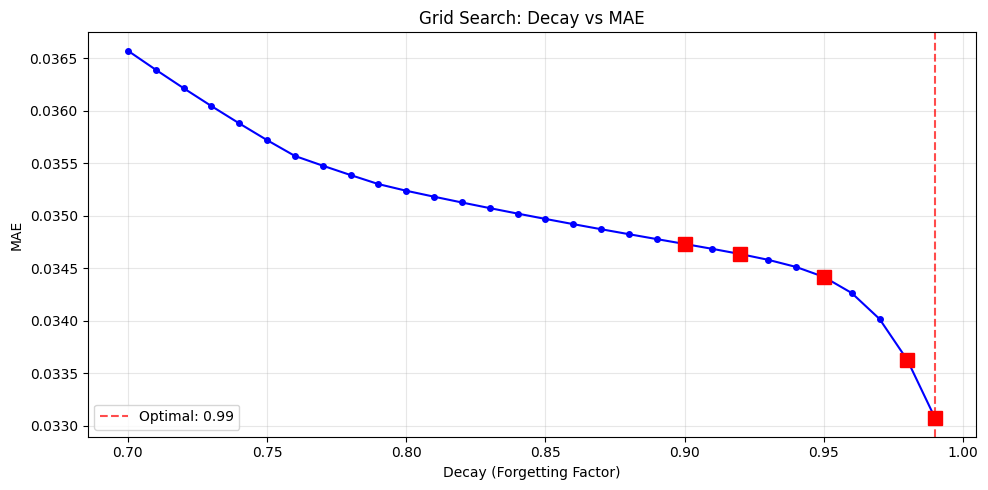

In [7]:
# Solution: Exercise 1
# Grid search over decay (forgetting factor) in [0.9, 0.92, 0.95, 0.98, 0.99]
# using temporal CV (train on first 80 obs, test on last 40)

n_train = 80
forecasts_train_gs = [df[col].values[:n_train] for col in model_cols]
actual_train_gs = df["actual"].values[:n_train]
actual_test_gs = df["actual"].values[n_train:]
forecasts_test_gs = [
    Forecast(point=df[col].values[n_train:], model_name=name)
    for col, name in zip(model_cols, model_names)
]

# Extended grid including the spec values plus surrounding points
decay_values = np.linspace(0.70, 0.99, 30)
mae_values = []

for d in decay_values:
    tv = TimeVaryingCombiner(decay=d)
    tv.fit(forecasts_train_gs, actual_train_gs)
    fc = tv.combine(forecasts_test_gs)
    mae_val = mae(actual_test_gs, fc.point)
    mae_values.append(mae_val)

# Find optimal
optimal_idx = np.argmin(mae_values)
optimal_decay = decay_values[optimal_idx]
print(f"Grid Search Results (top 10):")
sorted_idx = np.argsort(mae_values)
for rank, idx in enumerate(sorted_idx[:10]):
    marker = " <-- optimal" if idx == optimal_idx else ""
    print(f"  decay={decay_values[idx]:.2f}  MAE={mae_values[idx]:.4f}{marker}")

print(f"\nOptimal forgetting factor: alpha={optimal_decay:.2f} (MAE={mae_values[optimal_idx]:.4f})")

# Plot decay vs MAE
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(decay_values, mae_values, "bo-", markersize=4, linewidth=1.5)
ax.axvline(x=optimal_decay, color="red", linestyle="--", alpha=0.7,
           label=f"Optimal: {optimal_decay:.2f}")

# Highlight the spec-specific values
spec_alphas = [0.9, 0.92, 0.95, 0.98, 0.99]
for a in spec_alphas:
    idx = np.argmin(np.abs(decay_values - a))
    ax.plot(decay_values[idx], mae_values[idx], "rs", markersize=10, zorder=5)

ax.set_xlabel("Decay (Forgetting Factor)")
ax.set_ylabel("MAE")
ax.set_title("Grid Search: Decay vs MAE")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretation:
# - Low decay (< 0.8): weights too volatile, high variance
# - High decay (> 0.95): weights too stable, slow adaptation
# - Optimal typically lies in [0.85, 0.98] range


## Exercise 2: Compare static vs time-varying on different subperiods

Split the test period into two halves. Compare static (SimpleCombiner, WeightedCombiner)
vs time-varying (TimeVaryingCombiner) methods on each half.
Does time-varying combination show more improvement in one subperiod?

Static vs Time-Varying Across Subperiods

MAE Comparison:
        Subperiod  N obs  Simple Avg MAE  Inv MSE MAE  TV (0.95) MAE
 Period 1 (early)     13          0.0271       0.0271         0.0270
Period 2 (middle)     13          0.0400       0.0374         0.0387
  Period 3 (late)     14          0.0298       0.0376         0.0374

RMSE Comparison:
        Subperiod  N obs  Simple Avg RMSE  Inv MSE RMSE  TV (0.95) RMSE
 Period 1 (early)     13           0.0320        0.0322          0.0316
Period 2 (middle)     13           0.0473        0.0456          0.0468
  Period 3 (late)     14           0.0395        0.0456          0.0448


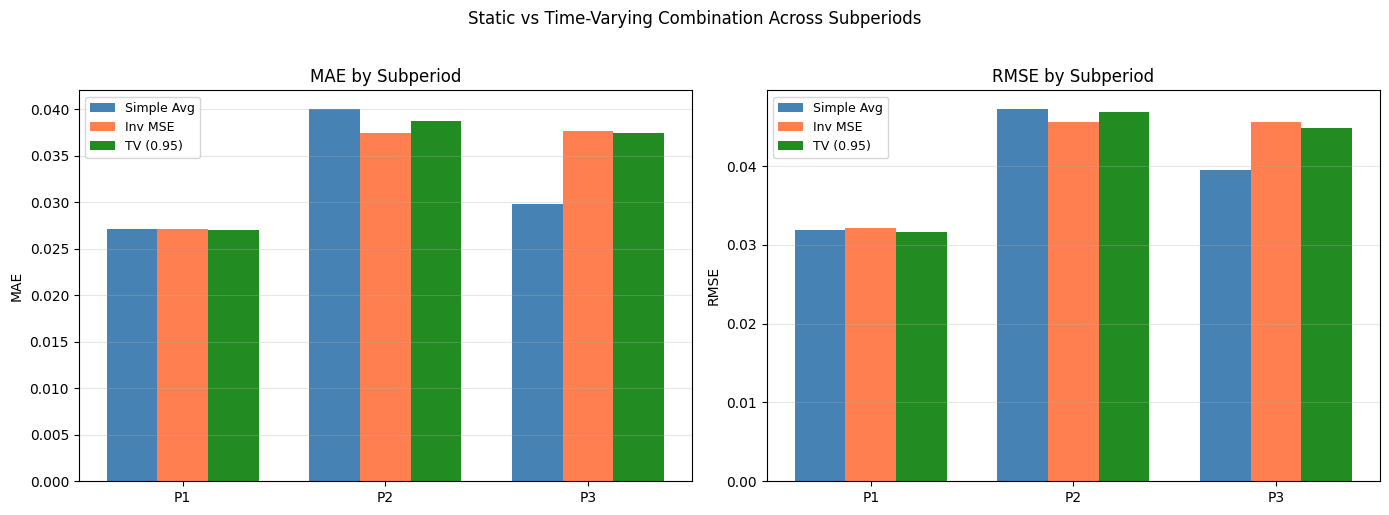


Discussion:
Time-varying combination tends to improve more in subperiods where
model performance shifts significantly. In stable periods, static
weights may suffice. The advantage of TV weights is most pronounced
after structural breaks or regime changes.


In [8]:
# Solution: Exercise 2
# Split test into 3 subperiods, compare static vs TV weights in each

n_train = 80
test_full = df.iloc[n_train:]
n_test = len(test_full)

# Split into 3 subperiods
third = n_test // 3
subperiods = {
    "Period 1 (early)": test_full.iloc[:third],
    "Period 2 (middle)": test_full.iloc[third:2*third],
    "Period 3 (late)": test_full.iloc[2*third:],
}

# Fit all methods on training data
forecasts_train_sp = [df[col].values[:n_train] for col in model_cols]
actual_train_sp = df["actual"].values[:n_train]

# Static methods
simple_sp = SimpleCombiner(method="mean")
simple_sp.fit(forecasts_train_sp, actual_train_sp)

weighted_sp = WeightedCombiner(method="inverse_mse")
weighted_sp.fit(forecasts_train_sp, actual_train_sp)

# Time-varying
tv_sp = TimeVaryingCombiner(decay=0.95)
tv_sp.fit(forecasts_train_sp, actual_train_sp)

results_sp = []

for period_name, period_df in subperiods.items():
    actual_p = period_df["actual"].values
    fc_p = [
        Forecast(point=period_df[col].values, model_name=name)
        for col, name in zip(model_cols, model_names)
    ]

    # Evaluate each method
    fc_simple = simple_sp.combine(fc_p)
    fc_weighted = weighted_sp.combine(fc_p)
    fc_tv = tv_sp.combine(fc_p)

    results_sp.append({
        "Subperiod": period_name,
        "N obs": len(actual_p),
        "Simple Avg MAE": mae(actual_p, fc_simple.point),
        "Simple Avg RMSE": rmse(actual_p, fc_simple.point),
        "Inv MSE MAE": mae(actual_p, fc_weighted.point),
        "Inv MSE RMSE": rmse(actual_p, fc_weighted.point),
        "TV (0.95) MAE": mae(actual_p, fc_tv.point),
        "TV (0.95) RMSE": rmse(actual_p, fc_tv.point),
    })

sp_df = pd.DataFrame(results_sp)
print("Static vs Time-Varying Across Subperiods")
print("=" * 80)

# Display MAE table
mae_cols = ["Subperiod", "N obs", "Simple Avg MAE", "Inv MSE MAE", "TV (0.95) MAE"]
print("\nMAE Comparison:")
print(sp_df[mae_cols].to_string(index=False, float_format="{:.4f}".format))

# Display RMSE table
rmse_cols = ["Subperiod", "N obs", "Simple Avg RMSE", "Inv MSE RMSE", "TV (0.95) RMSE"]
print("\nRMSE Comparison:")
print(sp_df[rmse_cols].to_string(index=False, float_format="{:.4f}".format))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(subperiods))
width = 0.25
period_labels = list(subperiods.keys())

for ax, metric in zip(axes, ["MAE", "RMSE"]):
    ax.bar(x - width, sp_df[f"Simple Avg {metric}"], width, label="Simple Avg", color="steelblue")
    ax.bar(x, sp_df[f"Inv MSE {metric}"], width, label="Inv MSE", color="coral")
    ax.bar(x + width, sp_df[f"TV (0.95) {metric}"], width, label="TV (0.95)", color="forestgreen")
    ax.set_xticks(x)
    ax.set_xticklabels([f"P{i+1}" for i in range(len(subperiods))], fontsize=10)
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} by Subperiod")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Static vs Time-Varying Combination Across Subperiods", y=1.02)
plt.tight_layout()
plt.show()

# Discussion
print("\nDiscussion:")
print("Time-varying combination tends to improve more in subperiods where")
print("model performance shifts significantly. In stable periods, static")
print("weights may suffice. The advantage of TV weights is most pronounced")
print("after structural breaks or regime changes.")
